<a href="https://colab.research.google.com/github/amaynagar/GNSSerrorprediction/blob/main/g01errorpred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/G01_data.csv")
df["target_time"] = pd.to_datetime(df["target_time"])

# 👉 USE ALL THREE
dataset = df[['R_Error','A_Error','C_Error']]   # shape: (N, 3)

In [ ]:
dataset.head()

,R_Error,A_Error,C_Error
0,-2.064754,1.612437,-0.460026
1,-2.090696,1.661811,-0.405673
2,-2.114427,1.719117,-0.344207
3,-2.135284,1.780467,-0.277897
4,-2.153122,1.846037,-0.206832


In [ ]:
dataset = df[['R_Error','A_Error','C_Error']].values

In [ ]:
total_len = len(dataset)

train_len = int(total_len * 0.6)
val_len = int(total_len * 0.2)

train_data = dataset[:train_len]
val_data = dataset[train_len:train_len+val_len]
test_data = dataset[train_len+val_len:]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

train_data = scaler.fit_transform(train_data)
val_data = scaler.transform(val_data)
test_data = scaler.transform(test_data)

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])   # (seq_length, 3)
        y.append(data[i])               # (3)

    return np.array(X), np.array(y)

seq_length = 20

x_train, y_train = create_sequences(train_data, seq_length)
x_val, y_val = create_sequences(val_data, seq_length)
x_test, y_test = create_sequences(test_data, seq_length)

print(x_train.shape)   # (samples, 20, 3)
print(y_train.shape)   # (samples, 3)

(75665, 20, 3)
(75665, 3)


In [ ]:
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
model = keras.models.Sequential()

model.add(keras.layers.LSTM(64, return_sequences=True,input_shape=(seq_length, 3),dropout=0.1, recurrent_dropout=0.1))

model.add(keras.layers.LSTM(32, dropout=0.1))

model.add(keras.layers.Dense(64, activation="relu"))

#OUTPUT = 3 (R, A, C)
model.add(keras.layers.Dense(3))

model.compile(optimizer=keras.optimizers.Adam(0.0005),loss="mae",metrics=[keras.metrics.RootMeanSquaredError()])

earlystop = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

history = model.fit(x_train, y_train,validation_data=(x_val, y_val),epochs=50,batch_size=64,callbacks=[earlystop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 101s 80ms/step - loss: 0.0281 - root_mean_squared_error: 0.9324 - val_loss: 0.0043 - val_root_mean_squared_error: 0.0058
Epoch 2/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 90s 76ms/step - loss: 0.0207 - root_mean_squared_error: 0.6997 - val_loss: 0.0043 - val_root_mean_squared_error: 0.0057
Epoch 3/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - loss: 0.0150 - root_mean_squared_error: 0.5391 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0046
Epoch 4/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 84s 71ms/step - loss: 0.0139 - root_mean_squared_error: 0.4769 - val_loss: 0.0039 - val_root_mean_squared_error: 0.0050
Epoch 5/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 86s 73ms/step - loss: 0.0131 - root_mean_squared_error: 0.4712 - val_loss: 0.0042 - val_root_mean_squared_error: 0.0054
Epoch 6/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 85s 72ms/step - loss: 0.0113 - root_mean_squared_error: 0.3478 - val_loss: 0.0041 - val_root_mean_squared_error: 0.0053
Epoch 7/50
1183/1183 ━━━━━━

In [ ]:
test_loss, test_rmse = model.evaluate(x_test, y_test)
print("Test RMSE:", test_rmse)

788/788 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0033 - root_mean_squared_error: 0.0045
Test RMSE: 0.004548521712422371


In [ ]:
predictions = model.predict(x_test)

# Inverse scaling
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

788/788 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step


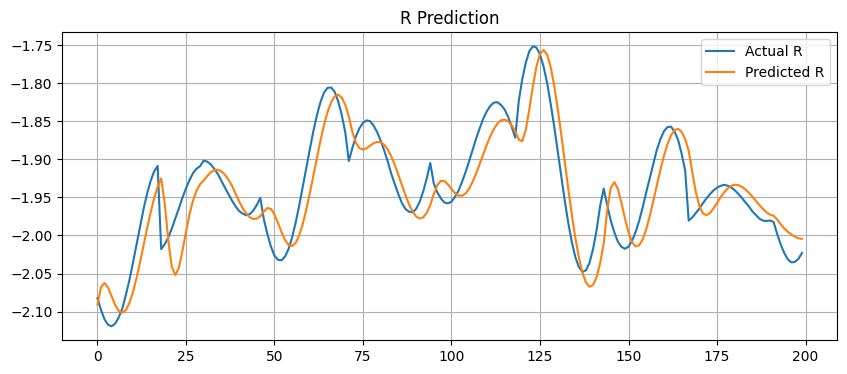

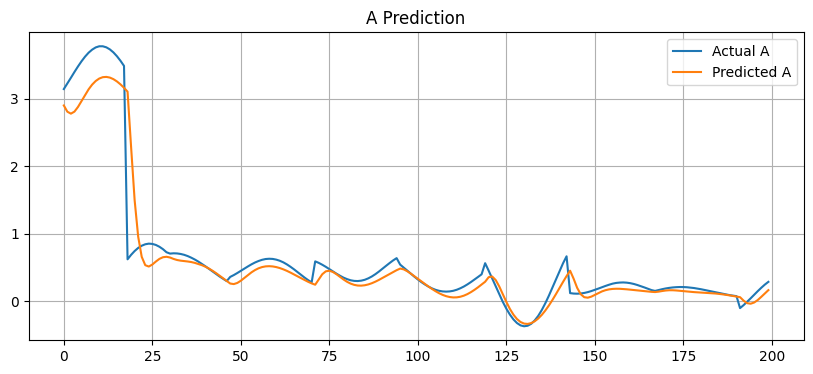

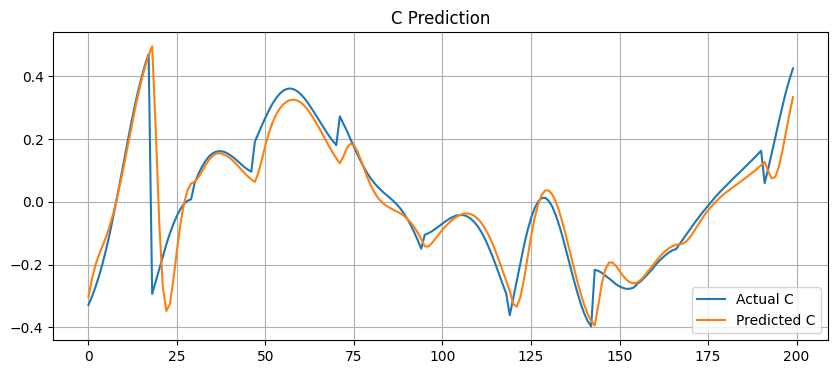

In [ ]:
import matplotlib.pyplot as plt

labels = ["R", "A", "C"]

for i in range(3):
    plt.figure(figsize=(10,4))
    plt.plot(y_test_actual[:200, i], label=f"Actual {labels[i]}")
    plt.plot(predictions[:200, i], label=f"Predicted {labels[i]}")
    plt.legend()
    plt.title(f"{labels[i]} Prediction")
    plt.grid()
    plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

labels = ["R", "A", "C"]

for i in range(3):
    mse = mean_squared_error(y_test_actual[:, i], predictions[:, i])
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_actual[:, i], predictions[:, i])

    print(f"----- {labels[i]} Component -----")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"R²   : {r2:.6f}")
    print()

----- R Component -----
MSE  : 0.002758
RMSE : 0.052517
R²   : 0.888818

----- A Component -----
MSE  : 0.037636
RMSE : 0.194000
R²   : 0.943355

----- C Component -----
MSE  : 0.007745
RMSE : 0.088006
R²   : 0.966239

